In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

✅ Sukses! Dataset asli berhasil dimuat!


In [ ]:
# 2. Mencoba membaca dataset asli
try:
    # Membaca file CSV yang diunggah ke Colab
    df = pd.read_csv('updated_pollution_dataset.csv')
    print("✅ Sukses! Dataset asli berhasil dimuat!")
except FileNotFoundError:
    print("❌ Gagal! File 'updated_pollution_dataset.csv' tidak ditemukan. Pastikan file sudah diunggah.")

In [5]:
# 3. Menampilkan Struktur Data dasar
print("\n=== INFORMASI STRUKTUR DATA ===")
print(df.info())


=== INFORMASI STRUKTUR DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB
None


In [6]:
print("\n=== 5 DATA PERTAMA (HEAD) ===")
print(df.head())


=== 5 DATA PERTAMA (HEAD) ===
   Temperature  Humidity  PM2.5  PM10   NO2   SO2    CO  \
0         29.8      59.1    5.2  17.9  18.9   9.2  1.72   
1         28.3      75.6    2.3  12.2  30.8   9.7  1.64   
2         23.1      74.7   26.7  33.8  24.4  12.6  1.63   
3         27.1      39.1    6.1   6.3  13.5   5.3  1.15   
4         26.5      70.7    6.9  16.0  21.9   5.6  1.01   

   Proximity_to_Industrial_Areas  Population_Density Air Quality  
0                            6.3                 319    Moderate  
1                            6.0                 611    Moderate  
2                            5.2                 619    Moderate  
3                           11.1                 551        Good  
4                           12.7                 303        Good  


In [9]:
print("\n=== DISTRIBUSI KELAS TARGET (KUALITAS UDARA) ===")
print(df['Air Quality'].value_counts())


=== DISTRIBUSI KELAS TARGET (KUALITAS UDARA) ===
Air Quality
Good         2000
Moderate     1500
Poor         1000
Hazardous     500
Name: count, dtype: int64


In [11]:
# 4. Melakukan encoding target string ke numerik untuk keperluan analisis korelasi
df_encoded = df.copy()
le = LabelEncoder()
df_encoded['Air_Quality_Num'] = le.fit_transform(df_encoded['Air Quality'])


In [12]:
# 5. Visualisasi Grafik Korelasi dan Pola Data
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

/tmp/ipykernel_1980/2326733653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Air Quality', order=['Good', 'Moderate', 'Poor', 'Hazardous'], palette='viridis')


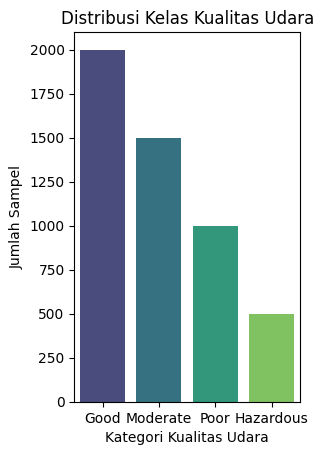

In [14]:
# Plot Kiri: Distribusi Kelas Target
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Air Quality', order=['Good', 'Moderate', 'Poor', 'Hazardous'], palette='viridis')
plt.title('Distribusi Kelas Kualitas Udara')
def_xlabel = plt.xlabel('Kategori Kualitas Udara')
def_ylabel = plt.ylabel('Jumlah Sampel')

Text(0, 0.5, 'Kelembapan (%)')

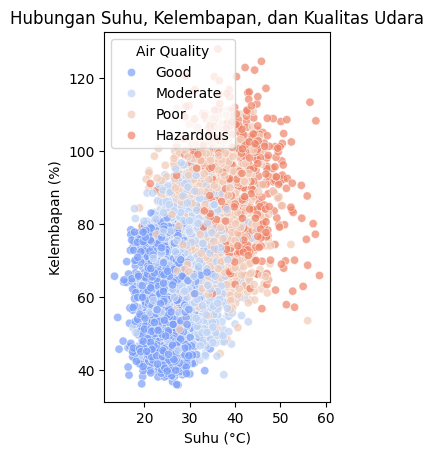

In [16]:
# Plot Kanan: Hubungan Suhu vs Kelembapan
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Temperature', y='Humidity', hue='Air Quality',
                hue_order=['Good', 'Moderate', 'Poor', 'Hazardous'], palette='coolwarm', alpha=0.7)
plt.title('Hubungan Suhu, Kelembapan, dan Kualitas Udara')
plt.xlabel('Suhu (°C)')
plt.ylabel('Kelembapan (%)')

In [17]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [18]:
# 6. Menampilkan korelasi fitur numerik dengan target numerik
print("\n=== MATRIKS KORELASI TERHADAP TARGET KUALITAS UDARA ===")
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
correlation_matrix = df_encoded[numeric_cols].corr()
print(correlation_matrix['Air_Quality_Num'].sort_values(ascending=False))


=== MATRIKS KORELASI TERHADAP TARGET KUALITAS UDARA ===
Air_Quality_Num                  1.000000
CO                               0.618933
NO2                              0.521952
Temperature                      0.501446
SO2                              0.497263
Population_Density               0.432361
Humidity                         0.430633
PM10                             0.366493
PM2.5                            0.268432
Proximity_to_Industrial_Areas   -0.715686
Name: Air_Quality_Num, dtype: float64


df.info(): Ini menampilkan jumlah baris dan tipe data. Pastikan tidak ada data kosong (Non-Null Count harus sama dengan jumlah baris). Jika aman, artinya tidak perlu imputasi data hilang.

value_counts(): Bagian ini krusial untuk melihat apakah data kita seimbang (balanced) atau berat sebelah (imbalanced).

Grafik Kiri (Bar Chart): Menunjukkan visualisasi distribusi kelas. Apakah kelas Good jauh lebih banyak daripada kelas Hazardous?

Grafik Kanan (Scatter Plot): Di sini kamu bisa melihat bagaimana penyebaran warna kelas berdasarkan temperatur (X-axis) dan kelembapan (Y-axis).

Matriks Korelasi: Angka mendekati 1.0 menunjukkan korelasi positif kuat, sedangkan mendekati -1.0 menunjukkan korelasi negatif kuat terhadap target kita.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [20]:
if 'df' not in locals():
    print("⚠️ Error: Variabel 'df' tidak ditemukan! Pastikan kamu sudah menjalankan Cell Langkah 1 (EDA) di atas terlebih dahulu.")
else:
    print("🔄 Memulai proses Preprocessing...")

🔄 Memulai proses Preprocessing...


In [22]:
    # 1. ENCODING LABEL TARGET
    # Mengubah teks Kategori menjadi angka (0, 1, 2, 3) secara berurutan
    le = LabelEncoder()
    df['Air_Quality_Encoded'] = le.fit_transform(df['Air Quality'])
    class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("✅ Mapping target berhasil:", class_mapping)

✅ Mapping target berhasil: {'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Poor': np.int64(3)}


In [25]:
# 2. FEATURE ENGINEERING (REKAYASA FITUR)
# Membuat Fitur Baru 1: Heat Humidity Index (HHI)
df['HHI'] = (df['Temperature'] * df['Humidity']) / 100

In [26]:
# Membuat Fitur Baru 2: PM Ratio (Rasio partikel halus vs kasar)
# Ditambahkan angka 1e-5 (angka sangat kecil) di pembagi agar tidak terjadi error pembagian dengan nol (zero division)
df['PM_ratio'] = df['PM2.5'] / (df['PM10'] + 1e-5)
print("✅ Rekayasa fitur selesai (Kolom 'HHI' dan 'PM_ratio' berhasil dibuat)!")

✅ Rekayasa fitur selesai (Kolom 'HHI' dan 'PM_ratio' berhasil dibuat)!
